# N-body Simulation and Lightcone Generation

This notebook demonstrates running N-body simulations with lightcone generation. Key features:

1. Generate Gaussian initial conditions
2. Compute LPT displacements and momenta at initial scale factor
3. Run N-body simulation with different geometry options:
   - `geometry=None`: Save 3D density fields (flexible but memory-intensive)
   - `geometry="flat"`: Compute flat-sky projections on-the-fly (memory-efficient)
   - `geometry="spherical"`: Compute HEALPix projections on-the-fly (memory-efficient)
4. Post-hoc painting of saved density fields to different projections

## Setup and Imports

In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax_cosmo as jc

from fwd_model_tools.field import FieldStatus, ParticleField, DensityField, FlatDensity, SphericalDensity
from fwd_model_tools.normal import gaussian_initial_conditions
from fwd_model_tools.pm import lpt, nbody
from fwd_model_tools.lensing_model import Planck18

/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


## Configuration

Set up simulation parameters. Using small mesh size for demonstration.

In [2]:
# Simulation parameters
mesh_size = (256, 256, 256)
box_size = (2000.0, 2000.0, 2000.0)  # in Mpc/h
observer_position = (0.5, 0.5, 0.5)
nside = 256
flatsky_npix = (256, 256)

# N-body parameters
t0 = 0.1  # Initial scale factor
t1 = 1.0  # Final scale factor (present day)
dt0 = 0.05  # Time step

# Random seed
key = jax.random.PRNGKey(42)
cosmo = Planck18()

print(f"Mesh size: {mesh_size}")
print(f"Box size: {box_size} Mpc/h")

Mesh size: (256, 256, 256)
Box size: (2000.0, 2000.0, 2000.0) Mpc/h


## Generate Initial Conditions

Create Gaussian initial conditions with the specified parameters.

In [3]:
gaussian_field = gaussian_initial_conditions(
    key=key,
    cosmo=cosmo,
    mesh_size=mesh_size,
    box_size=box_size,
    observer_position=observer_position,
    nside=nside,
    flatsky_npix=flatsky_npix,
)

print(f"Initial field: {gaussian_field}")
print(f"Status: {gaussian_field.status}")

Initial field: DensityField(array=Array(256, 256, 256), mesh_size=(256, 256, 256), box_size=(2000.0, 2000.0, 2000.0), status=initial_field, scale_factors_shape=(1,))
Status: FieldStatus.INITIAL_FIELD


## Compute LPT Initial Conditions

Compute LPT displacements and momenta at the initial scale factor `t0`.

In [4]:
dx_field, p_field = lpt(cosmo, gaussian_field, a=t0, order=1)

print(f"Displacement field: {dx_field}")
print(f"Array shape: {dx_field.array.shape}")
print(f"Scale factors: {dx_field.scale_factors}")

# Compute number of shells from field properties
nb_shells = 3
max_radius = dx_field.max_comoving_radius
density_plane_width = dx_field.density_width(nb_shells=nb_shells)
print(f"Max comoving radius: {max_radius} Mpc/h")
print(f"Density plane width: {density_plane_width} Mpc/h")
print(f"Number of shells: {nb_shells}")

shape of initial force: (256, 256, 256, 3)
growth factor shape: (1,)
Displacement field: ParticleField(array=Array(256, 256, 256, 3), mesh_size=(256, 256, 256), box_size=(2000.0, 2000.0, 2000.0), status=lpt1, scale_factors_shape=(1,))
Array shape: (256, 256, 256, 3)
Scale factors: [0.1]
Max comoving radius: 1000.0 Mpc/h
Density plane width: 333.3333333333333 Mpc/h
Number of shells: 3


## Run N-body with geometry=None

Run N-body simulation saving 3D density fields at each shell. This is flexible (can paint to any projection later) but memory-intensive.

In [7]:
# Run N-body with geometry=None to save 3D density fields
max_scale_factor = jc.background.a_of_chi(cosmo, dx_field.max_comoving_radius).squeeze()
ts = jnp.linspace(max_scale_factor, t1, nb_shells)
r_centers = jc.background.radial_comoving_distance(cosmo, ts)
density_snapshots = nbody(
    cosmo,
    dx_field,
    p_field,
    t1=t1,
    dt0=dt0,
    ts=ts,
    geometry='particles',
)

print(f"Density snapshots: {density_snapshots}")
print(f"Array shape: {density_snapshots.array.shape}")
print(f"Scale factors shape: {density_snapshots.scale_factors.shape}")

Density snapshots: ParticleField(array=Array(3, 256, 256, 256, 3), mesh_size=(256, 256, 256), box_size=(2000.0, 2000.0, 2000.0), status=lpt1, scale_factors_shape=(3,))
Array shape: (3, 256, 256, 256, 3)
Scale factors shape: (3,)


In [8]:
density_snapshots.scale_factors

Array([1.        , 0.86593459, 0.73186917], dtype=float64)

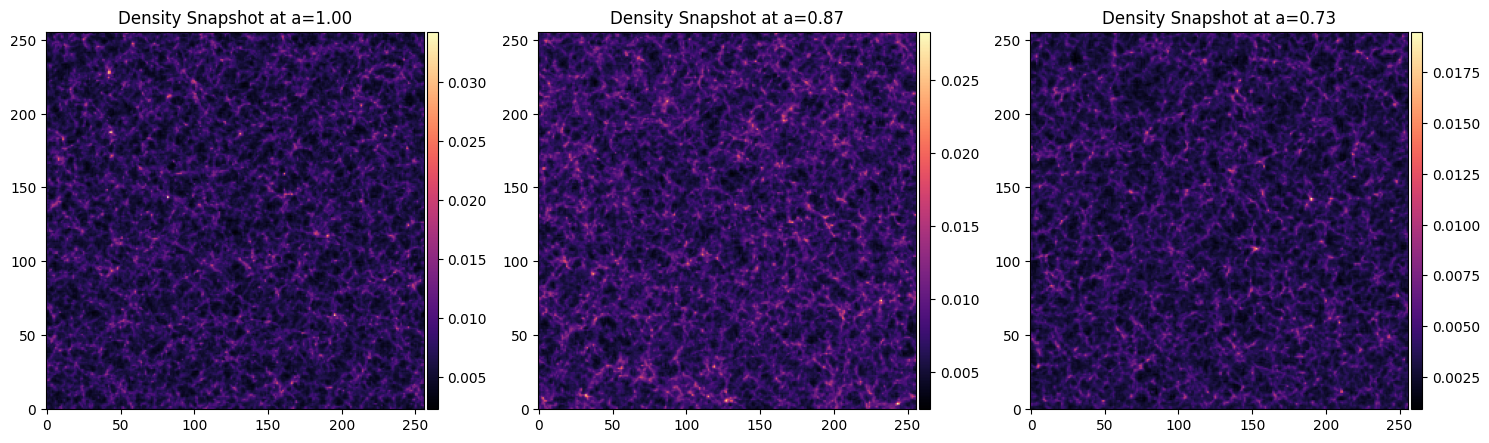

In [ ]:
flat_densities = density_snapshots.paint_2d(center=r_centers)
flat_densities.show(titles=[f"Density Snapshot at a={a:.2f}" for a in density_snapshots.scale_factors] , figsize=(15 , 10))

In [10]:
max_scale_factor = jc.background.a_of_chi(cosmo, density_snapshots.max_comoving_radius)
max_scale_factor

Array([0.73186917], dtype=float64)

In [11]:
density_snapshots.scale_factors

Array([1.        , 0.86593459, 0.73186917], dtype=float64)

In [15]:
ts

Array([0.73186917, 0.86593459, 1.        ], dtype=float64)

In [14]:
r_centers

Array([1001.4084527,  447.3842063,    0.       ], dtype=float64)

In [18]:
shifted_centers

Array([ 834.74178604,  280.71753963, -166.66666667], dtype=float64)

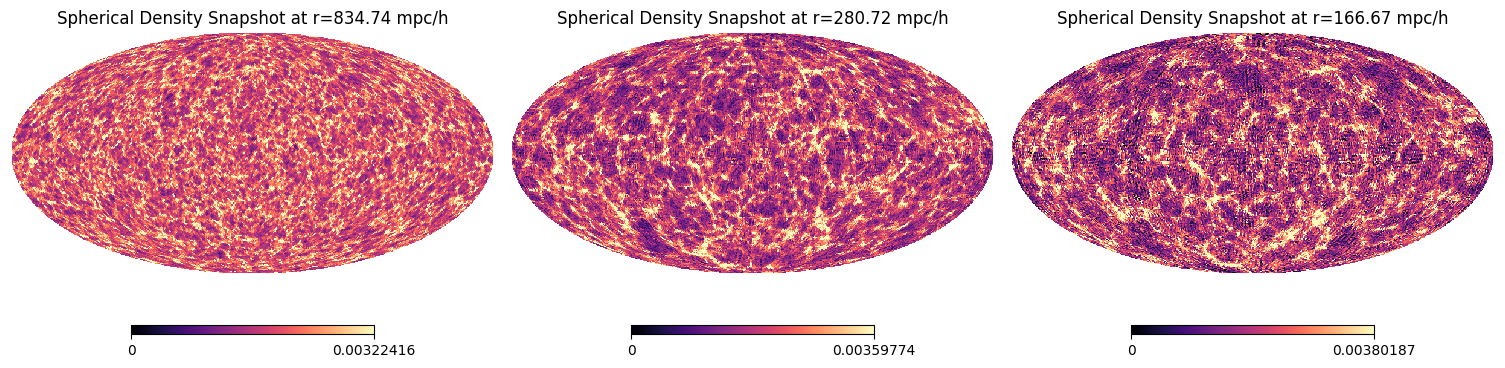

In [25]:
density_snapshots = density_snapshots.replace(nside=64)
shifted_centers = r_centers - density_snapshots.density_width(nb_shells=nb_shells)/2
shifted_centers = shifted_centers.at[-1].add(density_snapshots.density_width(nb_shells=nb_shells))
spherical_densities = density_snapshots.paint_spherical(center=shifted_centers , scheme='ngp' , batch_size=6 , paint_nside=256)
spherical_densities.show(titles=[f"Spherical Density Snapshot at r={r:.2f} mpc/h" for r in shifted_centers] , figsize=(15 , 10) , apply_log=False)